In [1]:
# SUPPORT VECTOR MACHINE :

In [ ]:
# Data set Description:
# Business Context:
# Pharmaceutical companies invest millions of dollars in clinical trials to test drug efficacy. However, 
# some drugs do not work for all patients due to individual differences in biology, metabolism, and
# pre-existing conditions.
# Traditional clinical trials take years to conclude, with high costs and risks.
# Machine learning models can help predict drug response early, saving time and resources.
# Personalized medicine ensures that patients receive the right drug at the right dose.

# Drug Response Classification (0 = No response, 1 = Positive response)
# Drug response classification refers to how a patient’s body reacts to a particular drug. This is a key 
# concept in pharmaceutical research and clinical trials, where researchers analyze whether a drug is
# effective or not based on biological responses.

In [ ]:
# Interpretation of Classification Labels:
# 1. 0 = No Response
# o The drug did not have a significant effect on the patient.
# o The patient’s condition remained unchanged after taking the drug.
# o The biomarkers (e.g., blood pressure, glucose level, heart rate) did not improve.
# o Possible reasons:
#  The drug is not suitable for the patient.
#  The dosage is ineffective.
#  The patient's metabolism is resistant to the drug.

In [ ]:
# 2. 1 = Positive Response
# o The drug had a beneficial effect on the patient.
# o The patient’s condition improved after taking the drug.
# o Biomarkers such as blood pressure, glucose levels, and enzyme activity show significant improvement.
# o Possible reasons:
#  The drug is effective for this patient.
#  The dosage is appropriate.
#  The patient’s metabolism responds well to the drug.

In [ ]:
# Why is This Classification Important?
# • Pharmaceutical Industry: Used to test new drugs and evaluate their effectiveness before FDA approval.
# • Personalized Medicine: Helps doctors prescribe drugs based on individual patient responses.
# • Machine Learning in Healthcare: Enables predictive models to forecast patient responses based on 
# medical data.

In [ ]:
# Task 1: Exploratory Data Analysis (EDA):

In [ ]:
# 1. Load the dataset and perform fundamental data exploration.

In [3]:
# Load the Dataset 
import pandas as pd 
df = pd.read_csv("Pharma_Industry (1).csv")

In [4]:
# Head of the Datset 
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [5]:
# Tail of Dataset 
df.tail()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
495,-1.553759,0.506938,0.817890,-0.661245,-1.345393,0
496,0.551476,1.714321,0.340589,1.712558,-0.496315,1
497,-1.072743,-0.221137,0.239247,1.112924,-0.285838,1
498,1.661259,0.245759,-0.457096,0.633355,0.657413,0
499,-1.143726,0.715320,0.108560,-0.509787,-0.250704,1


In [6]:
# Shape of Dataset 
df.shape

(500, 6)

In [7]:
# Columns of Dataset 
df.columns

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')

In [8]:
# General Information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [9]:
# Statistical summary 
df.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


In [10]:
# 2. Utilize histograms, box plots, or density plots to understand feature distributions.

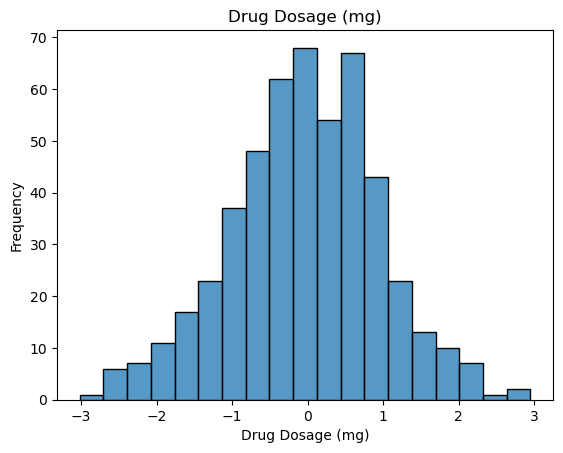

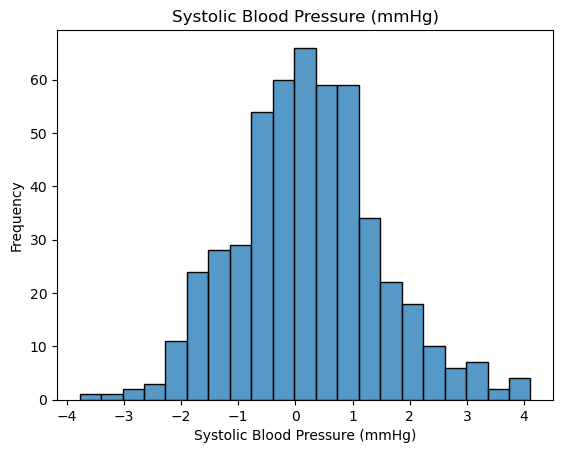

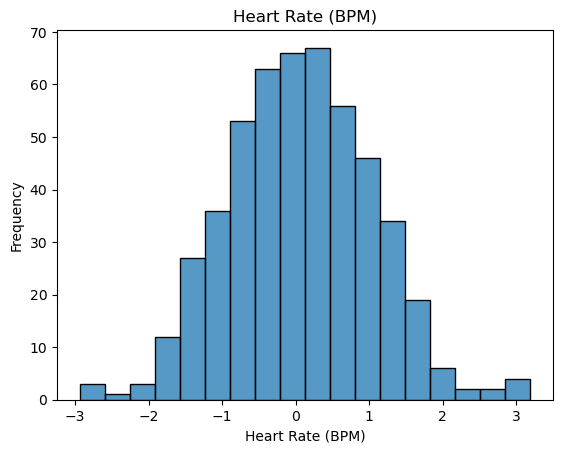

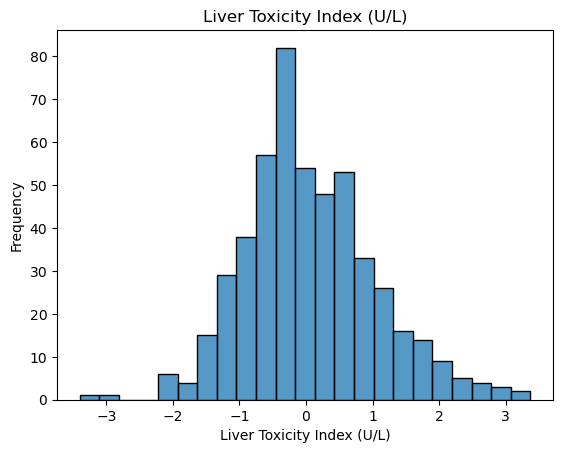

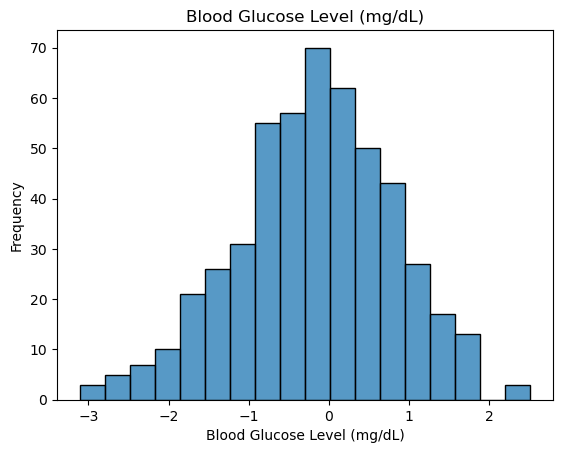

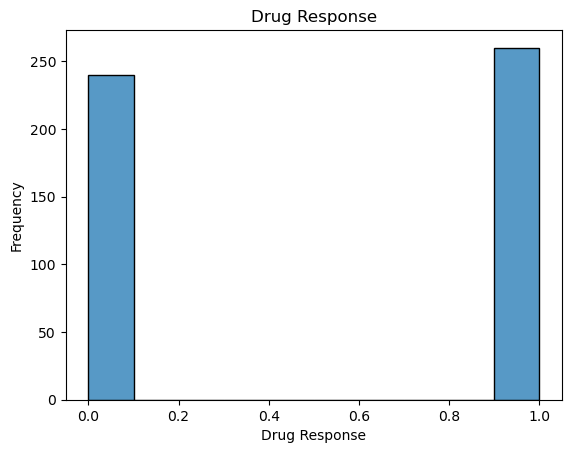

In [11]:
# Histogram Plot 
import matplotlib.pyplot as plt 
import seaborn as sns 
for col in df.columns:
    sns.histplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

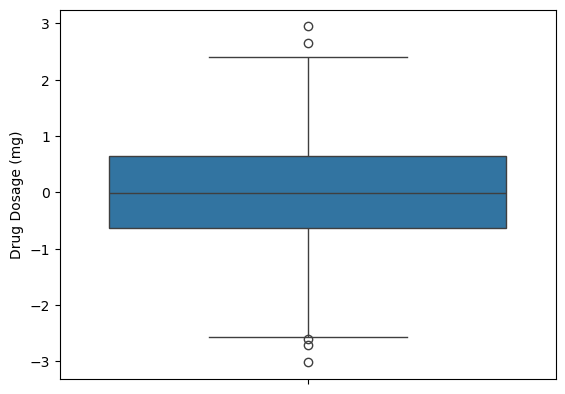

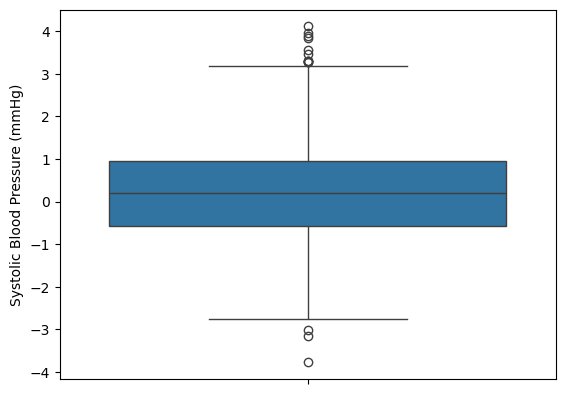

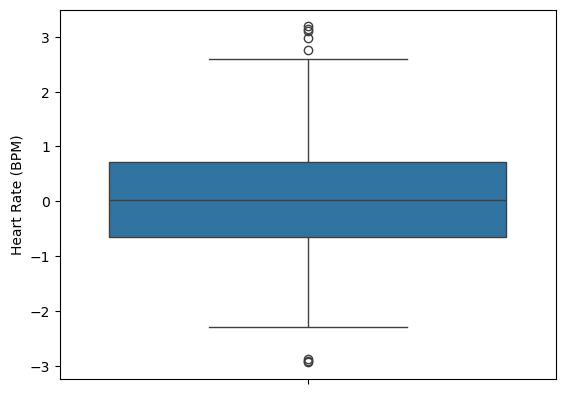

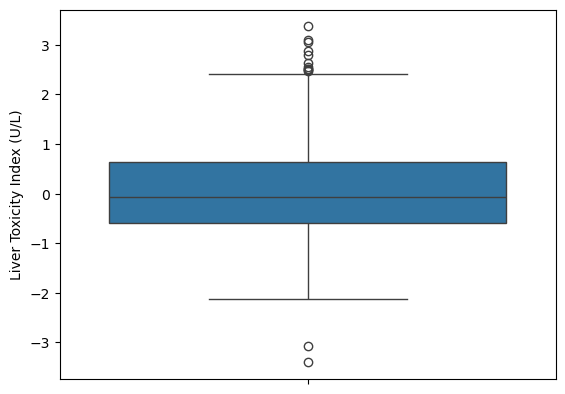

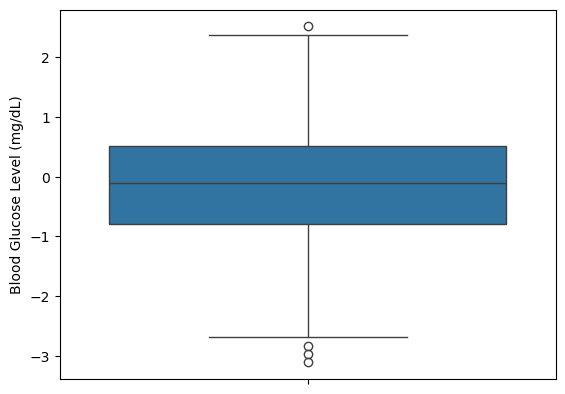

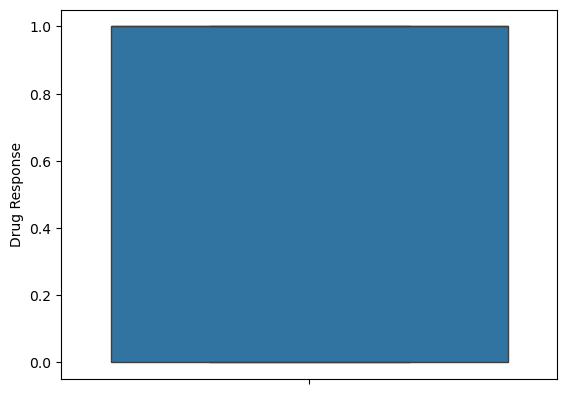

In [12]:
# Box Plot 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.columns:
    sns.boxplot(df[col])
    plt.show()

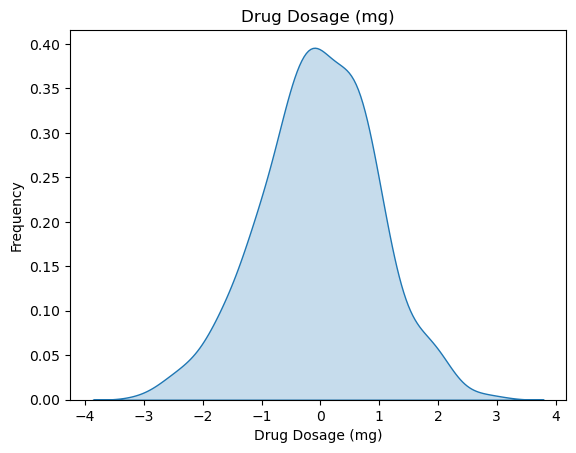

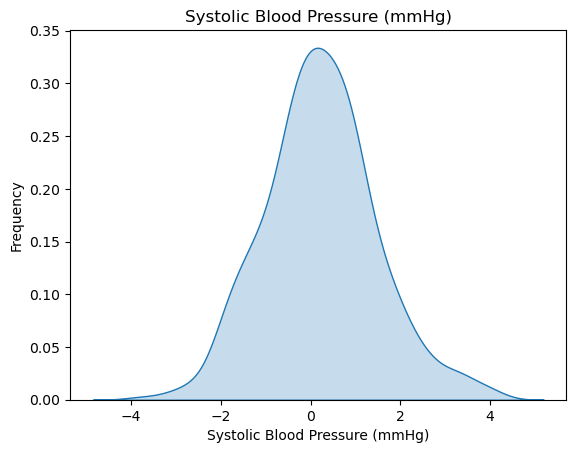

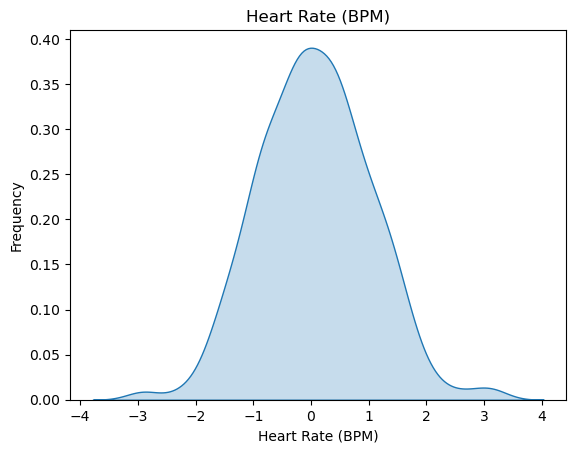

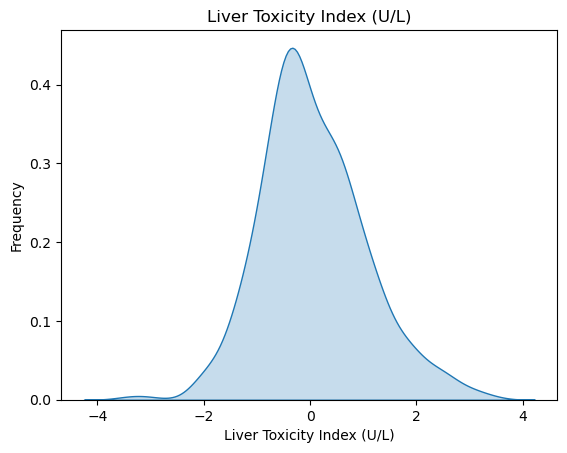

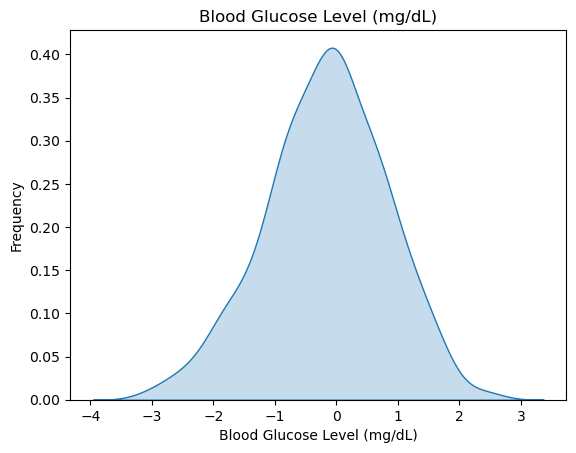

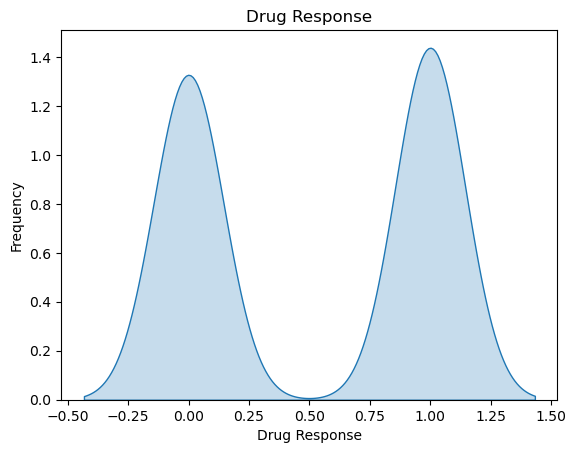

In [13]:
# Density Plot (KDE PLOT)
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.columns:
    sns.kdeplot(df[col], fill = True)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

In [14]:
# 3. Investigate feature correlations to discern relationships within the data.

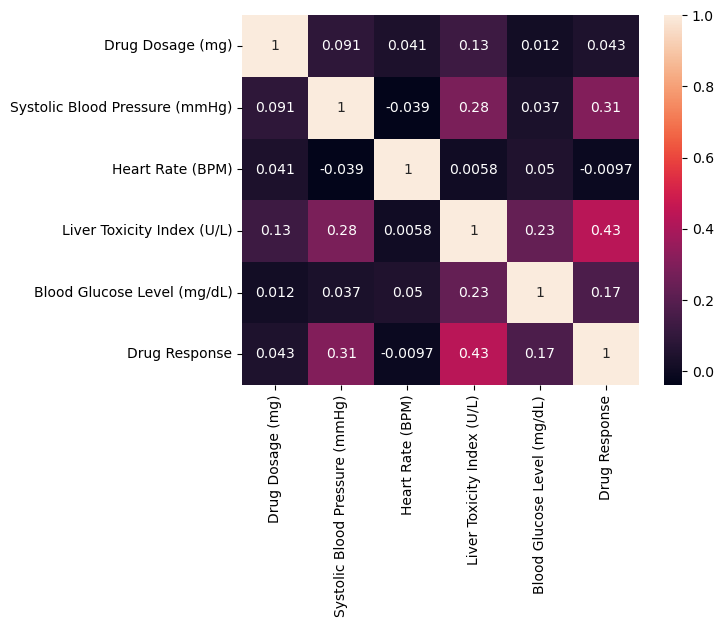

In [15]:
import matplotlib.pyplot as plt 
import seaborn as sns

sns.heatmap(df.corr(numeric_only = True), annot= True)
plt.show()

In [16]:
# Task 2: Data Preprocessing:

In [18]:
# 1. Encode categorical variables if necessary.
# There is no any Categorical Columns.

In [19]:
# Check Categorical Columns 
cat_cols = df.select_dtypes(include = 'object')
print("Categorical Columns:", cat_cols)

Categorical Columns: Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, ...]

[500 rows x 0 columns]


In [21]:
# 2. Split the dataset into training and testing sets.

In [22]:
# Extract Features and Target 
x = df.drop(columns = 'Drug Response')
y = df['Drug Response']

In [23]:
# Dataset Spliting 
from sklearn.model_selection import train_test_split
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

In [24]:
# Final Checks 
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (400, 5)
Shape of x_test: (100, 5)
Shape of y_train (400,)
Shape of y_test: (100,)


In [26]:
# Task 3: Data Visualization:

In [27]:
# 1. Employ scatter plots, pair plots, or relevant visualizations to comprehend feature 
# distributions and relationships.

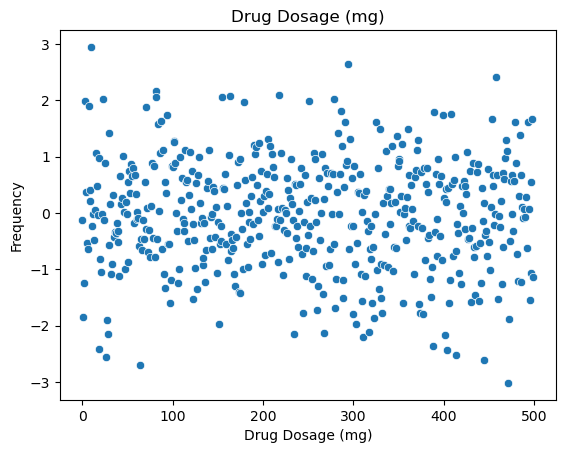

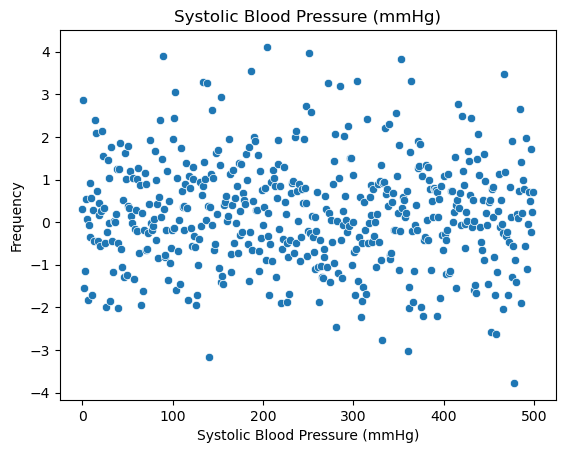

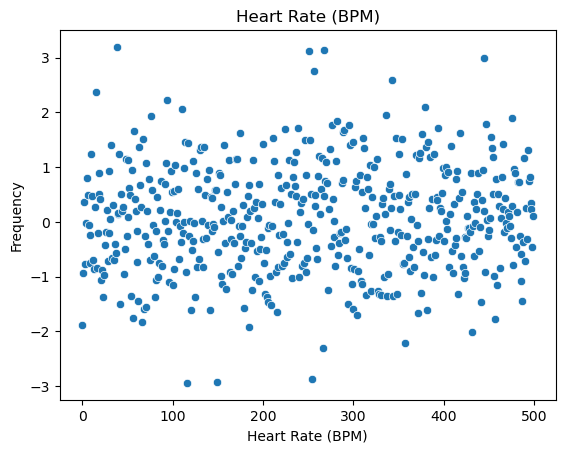

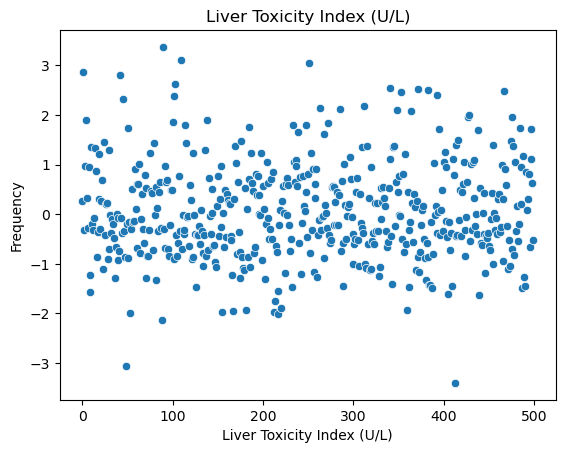

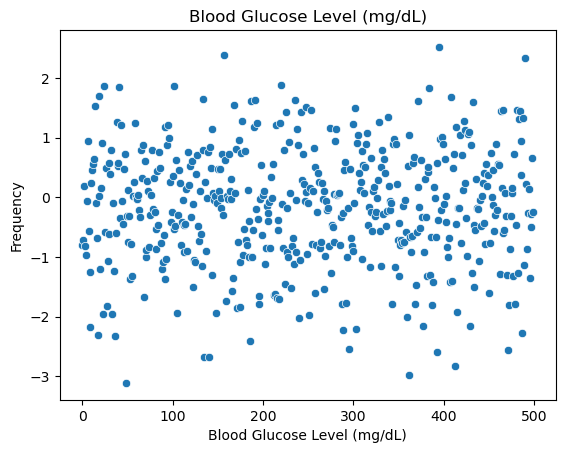

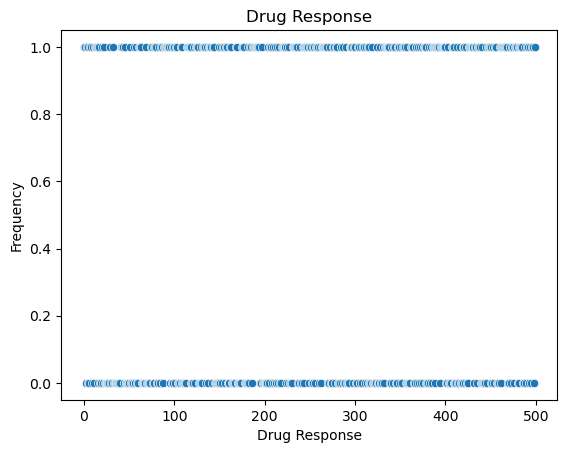

In [28]:
# Scatter Plot 
import matplotlib.pyplot as plt 
import seaborn as sns

for col in df.columns:
    sns.scatterplot(df[col])
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(col)
    plt.show()

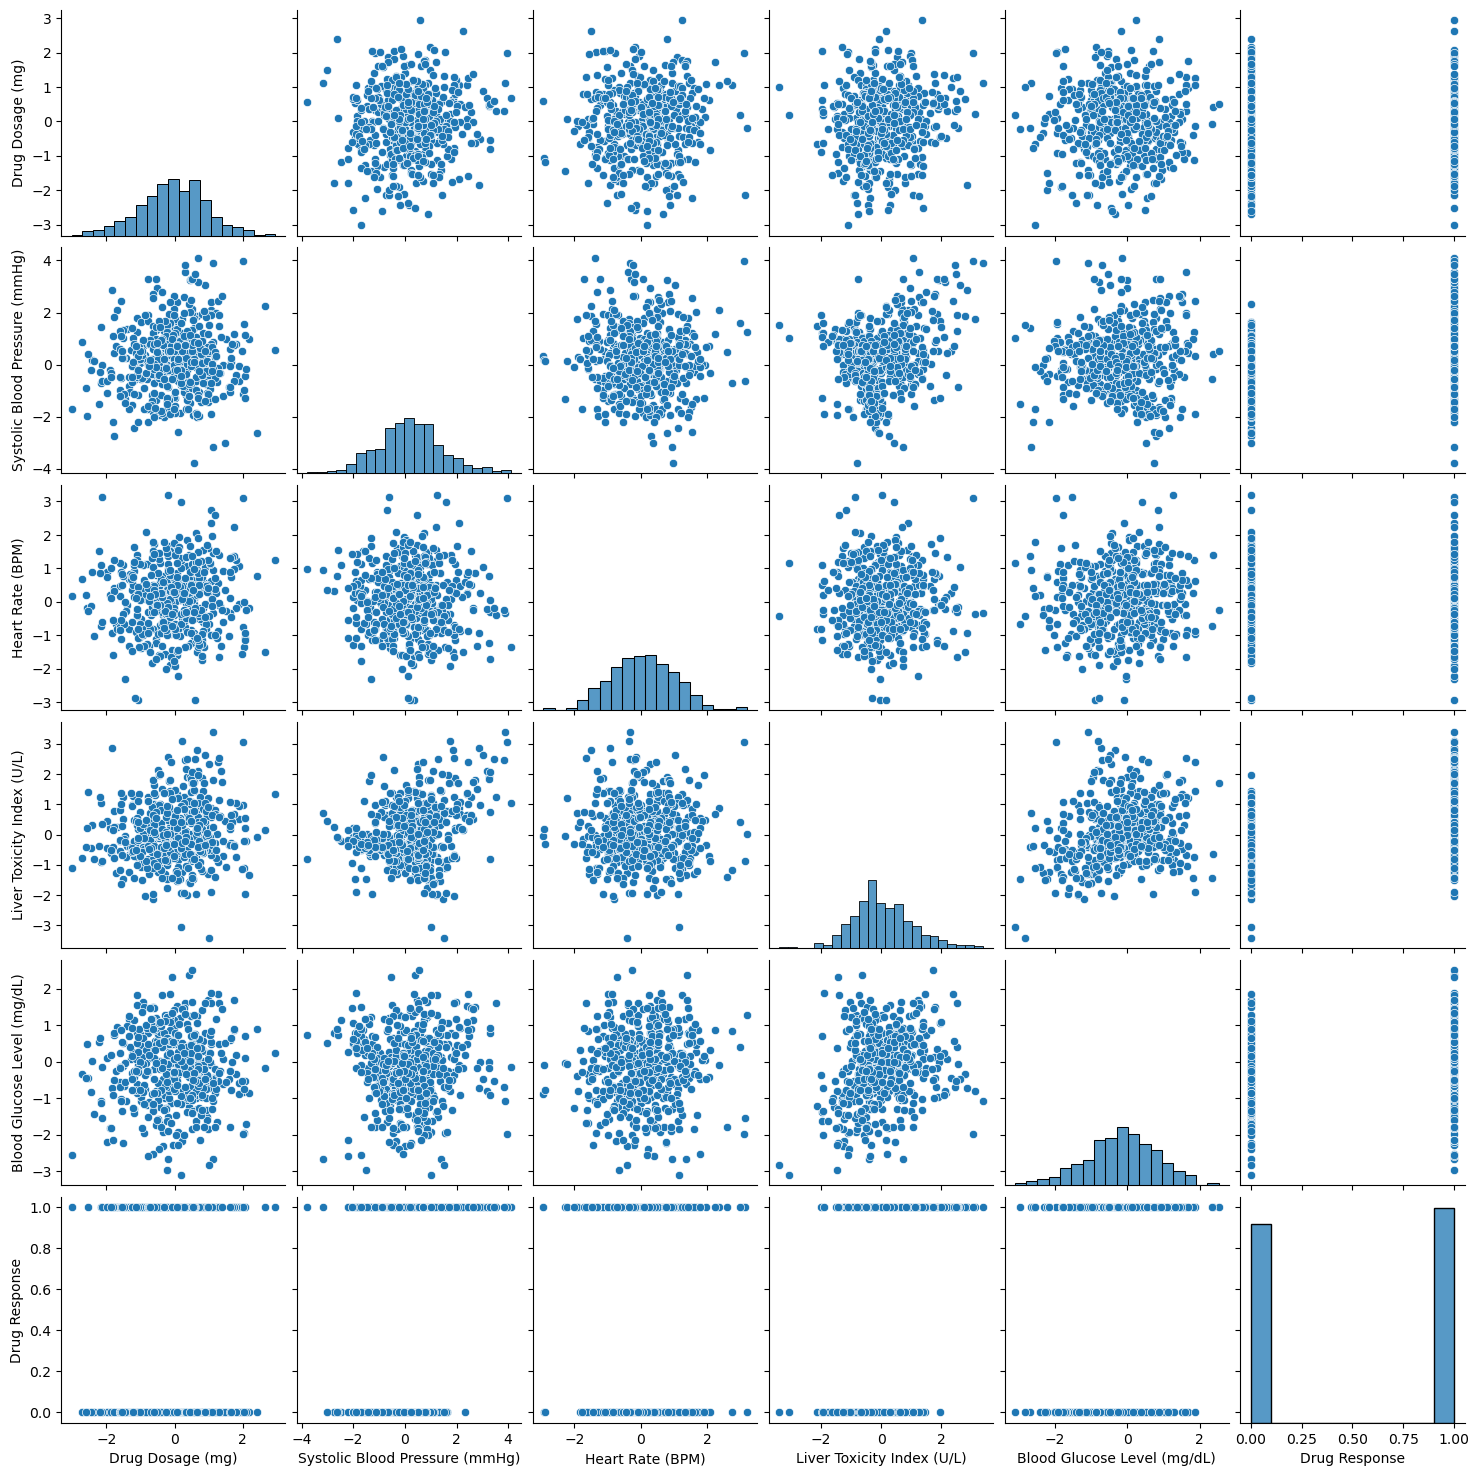

In [29]:
# Pair Plot 
import matplotlib.pyplot as plt 
import seaborn as sns


sns.pairplot(df)
plt.show()

In [30]:
# 2. Visualize class distributions to gauge dataset balance or imbalance.

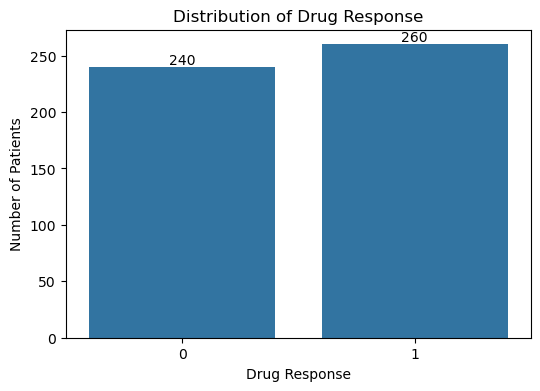

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Drug Response")

# Display count on each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Drug Response")
plt.xlabel("Drug Response")
plt.ylabel("Number of Patients")

plt.show()

In [32]:
# Print the class count 
print(df["Drug Response"].value_counts())

Drug Response
1    260
0    240
Name: count, dtype: int64


In [33]:
#Print the class percentages
print(df["Drug Response"].value_counts(normalize=True) * 100)

Drug Response
1    52.0
0    48.0
Name: proportion, dtype: float64


In [34]:
# Task 4: SVM Implementation:

In [36]:
# 1. Implement a basic SVM classifier using Python libraries like scikit-learn.

In [37]:
# Import Libraries

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
   )


# Implement basic SVM Classifier 
model = SVC(
    kernel="poly",     # Poly kernel
    C=1.0,            # Regularization parameter
    gamma="scale",    # Kernel coefficient
    random_state=42
)

In [38]:
# 2. Train the SVM model on the training data.

In [39]:
model.fit(x_train, y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [40]:
# 3. Evaluate model performance on the testing data using appropriate metrics
#     (e.g., accuracy, precision, recall, F1-score).

In [41]:
# Prediction on Testing Data 
y_pred = model.predict(x_test)

In [42]:
# Evaluate model performance on testing data using appropriater metrics 
# Import Libraries 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("="*60)
print("Kernel = poly\nC = 1.0")
print("="*60)

poly_acc = accuracy_score (y_test, y_pred)
print("Accuracy Score:", poly_acc)

poly_prec = precision_score(y_test, y_pred)
print("Precision Score:",poly_prec )

poly_rec =  recall_score(y_test, y_pred)
print("Recall Score:",poly_rec)

poly_f1 = f1_score(y_test, y_pred)
print("F1 Score:", poly_f1)

Kernel = poly
C = 1.0
Accuracy Score: 0.69
Precision Score: 0.8571428571428571
Recall Score: 0.5357142857142857
F1 Score: 0.6593406593406593


In [43]:
# Task 5: Visualization of SVM Results:

In [44]:
# 1. Visualize classification results on the testing data.

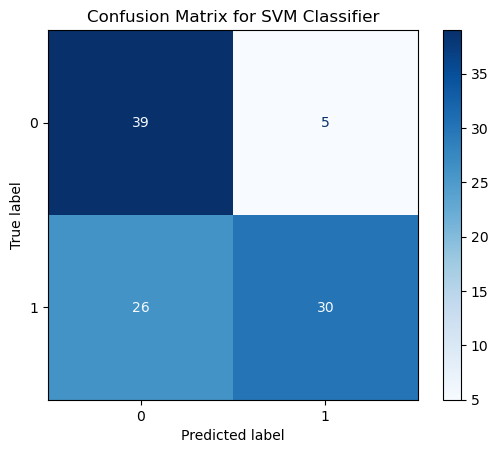

In [45]:
# 1. Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix for SVM Classifier")
plt.show()


In [46]:
# Interpretation
# Top-left (True Negative): Correctly predicted class 0.
# Top-right (False Positive): Incorrectly predicted class 1.
# Bottom-left (False Negative): Missed actual class 1.
# Bottom-right (True Positive): Correctly predicted class 1.

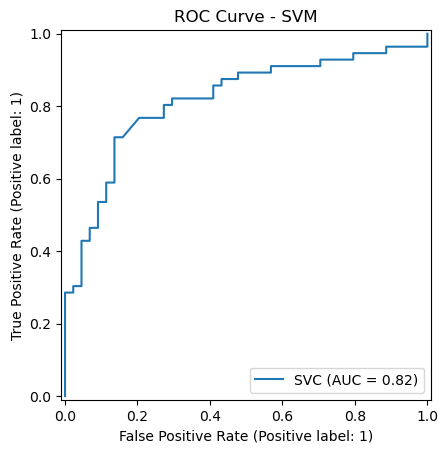

In [47]:
#2. ROC Curve (Binary Classification)
#If my target (Drug Response) has only 0 and 1, I can plot the ROC curve.


from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Enable probability estimates when creating the model
svm_model = SVC(kernel="poly", probability=True, random_state=42)

svm_model.fit(x_train, y_train)

RocCurveDisplay.from_estimator(svm_model, x_test, y_test)

plt.title("ROC Curve - SVM")
plt.show()

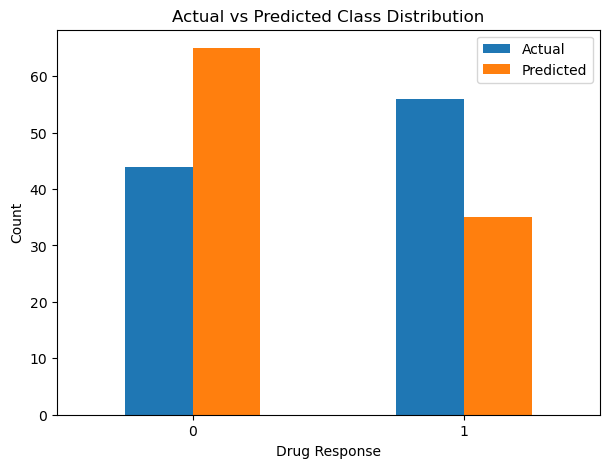

In [48]:
# 3. Actual vs Predicted Class Distribution
#This compares how many samples belong to each class versus how many the model predicted. 


import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Actual": y_test.value_counts().sort_index(),
    "Predicted": pd.Series(y_pred).value_counts().sort_index()
})

comparison.plot(kind="bar", figsize=(7,5))

plt.title("Actual vs Predicted Class Distribution")
plt.xlabel("Drug Response")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [50]:
# Task 6: Parameter Tuning and Optimization:

In [51]:
# 1. Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to 
# optimize performance.

In [52]:
# Implement SVM Classifier (Kernel = 'rbf', c = 0.1)
model = SVC(
    kernel="rbf",     # Rbf kernel
    C=1.0,            # Regularization parameter
    gamma="scale",    # Kernel coefficient
    random_state=42
)

# Train The Model 
model.fit(x_train, y_train)

# Predict The Model 
y_pred = model.predict(x_test)


# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
print("="*60)
print("Kernel = rbf\nC = 1.0")
print("="*60)

rbf_acc = accuracy_score (y_test, y_pred)
print("Accuracy Score:", rbf_acc)

rbf_prec = precision_score(y_test, y_pred)
print("Precision Score:",rbf_prec )

rbf_rec =  recall_score(y_test, y_pred)
print("Recall Score:",rbf_rec)

rbf_f1 = f1_score(y_test, y_pred)
print("F1 Score:", rbf_f1)

Kernel = rbf
C = 1.0
Accuracy Score: 0.82
Precision Score: 0.8653846153846154
Recall Score: 0.8035714285714286
F1 Score: 0.8333333333333334


In [53]:
# Implement SVM Classifier (kernel = sigmoid, c = 2.0)
model = SVC(
    kernel="sigmoid",     # Sigmoid kernel
    C=2.0,            # Regularization parameter
    gamma="scale",    # Kernel coefficient
    random_state=42
)

# Train The Model 
model.fit(x_train, y_train)

# Predict The Model 
y_pred = model.predict(x_test)


# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("="*60)
print("Kernel = Sigmoid \nC = 2.0")
print("="*60)

sigmoid_acc = accuracy_score (y_test, y_pred)
print("Accuracy Score:", sigmoid_acc)

sigmoid_prec = precision_score(y_test, y_pred)
print("Precision Score:",sigmoid_prec )

sigmoid_rec =  recall_score(y_test, y_pred)
print("Recall Score:",sigmoid_rec)

sigmoid_f1 = f1_score(y_test, y_pred)
print("F1 Score:", sigmoid_f1)

Kernel = Sigmoid 
C = 2.0
Accuracy Score: 0.74
Precision Score: 0.7586206896551724
Recall Score: 0.7857142857142857
F1 Score: 0.7719298245614035


In [54]:
# Implement SVM Classifier (kernel = lineaer, c = 1.0)
model = SVC(
    kernel="linear",     # Linear kernel
    C=1.0,            # Regularization parameter
    gamma="scale",    # Kernel coefficient
    random_state=42
)

# Train The Model 
model.fit(x_train, y_train)

# Predict The Model 
y_pred = model.predict(x_test)


# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


print("="*60)
print("Kernel = Linear \nC = 1.0")
print("="*60)


linear_acc = accuracy_score (y_test, y_pred)
print("Accuracy Score:", linear_acc)

linear_prec = precision_score(y_test, y_pred)
print("Precision Score:",linear_prec )

linear_rec =  recall_score(y_test, y_pred)
print("Recall Score:",linear_rec)

linear_f1 = f1_score(y_test, y_pred)
print("F1 Score:",linear_f1 )

Kernel = Linear 
C = 1.0
Accuracy Score: 0.78
Precision Score: 0.84
Recall Score: 0.75
F1 Score: 0.7924528301886793


In [55]:
# Task 7: Comparison and Analysis:

In [56]:
# 1. Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

In [57]:
# Comparison
compare = pd.DataFrame({
    "Comparison" : ["Linear", "Poly", "RBF","Sigmoid"] ,    
    "Accuracy" : [linear_acc, poly_acc, rbf_acc, sigmoid_acc],
    "Precision": [linear_prec, poly_prec, rbf_prec, sigmoid_prec],
    "Recall" : [linear_rec, poly_rec, rbf_prec, sigmoid_rec],
    "F1_Score" : [linear_f1, poly_f1, rbf_f1, sigmoid_f1]
    
})
compare.sort_values('Accuracy', ascending = False)

,Comparison,Accuracy,Precision,Recall,F1_Score
2,RBF,0.82,0.865385,0.865385,0.833333
0,Linear,0.78,0.840000,0.750000,0.792453
3,Sigmoid,0.74,0.758621,0.785714,0.771930
1,Poly,0.69,0.857143,0.535714,0.659341


In [ ]:
# 2. Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
# Strengths:
# The EDA showed that the dataset contains several numerical features (such as Age, BMI, Blood Pressure, Cholesterol, etc.), making it suitable for SVM after feature scaling.
# SVM performed well in distinguishing between the two classes of Drug Response (0 and 1), achieving good classification performance.
# The model produced high precision, indicating that when it predicted a positive drug response, the prediction was usually correct.
# The confusion matrix showed that most samples were classified correctly, demonstrating that SVM can effectively learn patterns in the pharmaceutical dataset.
# The RBF kernel (if it was your best-performing kernel) was able to capture non-linear relationships between patient characteristics and drug response.

# Weaknesses:
# The model achieved lower recall than precision, meaning it failed to identify some patients who actually had a positive drug response (false negatives).
# Model performance depends heavily on choosing the appropriate kernel, as well as tuning hyperparameters such as C and gamma.
# If the dataset becomes very large, SVM training can become computationally expensive and slower than models such as Random Forest.
# SVM is less interpretable than simpler models like Logistic Regression, making it more difficult to explain how individual features influence predictions.

In [ ]:
3. Discuss practical implications of SVM in real-world classification tasks.
Support Vector Machine (SVM) is a powerful supervised machine learning algorithm widely used for classification problems because of its ability to create accurate decision boundaries, especially when dealing with high-dimensional and non-linear data.

Practical Applications:
1. Healthcare and Pharmaceutical Industry
Predict whether a patient will respond positively or negatively to a particular drug.
Classify diseases based on patient symptoms and medical test results.
Assist doctors in early diagnosis and treatment planning.
2. Email Spam Detection
Classify emails as Spam or Not Spam based on their content.
3. Image Recognition
Recognize handwritten digits, faces, objects, or medical images such as X-rays and MRI scans.
4. Fraud Detection
Identify fraudulent banking or credit card transactions by distinguishing normal and suspicious activities.

In this pharmaceutical dataset, the SVM classifier can be used to predict a patients drug response 
(0 or 1) based on medical features such as age, BMI, blood pressure, cholesterol, and other health
indicators.

This prediction can help:
Support doctors in selecting suitable treatments.
Reduce ineffective prescriptions.
Improve personalized medicine by identifying patients who are more likely to respond to a specific drug.
Save time and reduce healthcare costs by assisting clinical decision-making.

Advantages in Real-World Applications
Provides high classification accuracy, especially for complex datasets.
Performs well with high-dimensional data.
Can model non-linear relationships using kernels such as the RBF kernel.
Generalizes well to unseen data when properly tuned.

Limitations
Requires feature scaling for optimal performance.
Training can be slow on very large datasets.
Performance depends on selecting the appropriate kernel and tuning hyperparameters (C and gamma).
Less interpretable than simpler models such as Logistic Regression.

In [ ]:
Conclusion:
Support Vector Machine is an effective classification algorithm with applications in healthcare, 
finance, cybersecurity, image recognition, and text classification. In the pharmaceutical industry, 
it can accurately predict drug response using patient health data, supporting clinical decision-making
and personalized treatment. Although SVM requires careful preprocessing and parameter tuning, its 
ability to model complex decision boundaries makes it a valuable tool for solving real-world
classification problems.